# Weather Data Analysis

## Project Overview

This project analyzes historical weather data from different cities to identify patterns and trends in temperature, rainfall, humidity, wind speed, and other weather conditions.

The dataset contains daily weather observations, including minimum and maximum temperature, average temperature, precipitation, wind speed, humidity, atmospheric pressure, dew point, cloud cover, and visibility-related weather information.

### Objectives

The main objectives of this project are to:

* Clean and prepare the weather dataset for analysis.
* Explore weather patterns across different cities.
* Analyze temperature, rainfall, humidity, and wind patterns.
* Compare weather conditions across seasons and months.
* Identify hot and cold days.
* Create meaningful visualizations to communicate important findings.
* Extract key insights from the historical weather data.

### Tools & Technologies

**Python | Pandas | NumPy | Matplotlib | Seaborn | Jupyter Notebook**

### Dataset

The analysis is based on historical daily weather observations covering multiple cities and years. The dataset is used to explore variations in weather conditions across different locations and time periods.


In [211]:
import pandas as pd
df = pd.read_csv("pakistan_weather_2000_2024.csv")

In [212]:
df.head()

,date,year,month,day,dayofweek,is_weekend,season,city,region,latitude,...,humidity,pressure,dew_point,cloud_cover,visibility,temp_range,is_hot_day,is_cold_day,rainfall_intensity,wind_category
0,1/1/2000,2000,1,1,5,1,Winter,Islamabad,Punjab,33.6844,...,76,1018.9,4.8,0,NaN,14.1,0,0,none,windy
1,1/2/2000,2000,1,2,6,1,Winter,Islamabad,Punjab,33.6844,...,77,1018.6,4.8,0,NaN,14.5,0,0,none,windy
2,1/3/2000,2000,1,3,0,0,Winter,Islamabad,Punjab,33.6844,...,76,1016.8,5.0,0,NaN,14.6,0,0,none,windy
3,1/4/2000,2000,1,4,1,0,Winter,Islamabad,Punjab,33.6844,...,75,1016.2,4.8,0,NaN,14.2,0,0,none,windy
4,1/5/2000,2000,1,5,2,0,Winter,Islamabad,Punjab,33.6844,...,77,1017.5,5.3,0,NaN,14.3,0,0,none,windy


In [113]:
df.shape

(31779, 27)

In [114]:
df.columns

Index(['date', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'season',
       'city', 'region', 'latitude', 'longitude', 'elevation', 'tmin', 'tmax',
       'tavg', 'prcp', 'wspd', 'humidity', 'pressure', 'dew_point',
       'cloud_cover', 'visibility', 'temp_range', 'is_hot_day', 'is_cold_day',
       'rainfall_intensity', 'wind_category'],
      dtype='object')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31779 entries, 0 to 31778
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                31779 non-null  object 
 1   year                31779 non-null  int64  
 2   month               31779 non-null  int64  
 3   day                 31779 non-null  int64  
 4   dayofweek           31779 non-null  int64  
 5   is_weekend          31779 non-null  int64  
 6   season              31779 non-null  object 
 7   city                31779 non-null  object 
 8   region              31779 non-null  object 
 9   latitude            31779 non-null  float64
 10  longitude           31779 non-null  float64
 11  elevation           31779 non-null  int64  
 12  tmin                31779 non-null  float64
 13  tmax                31779 non-null  float64
 14  tavg                31779 non-null  float64
 15  prcp                31779 non-null  float64
 16  wspd

In [116]:
## check for missing values
df.isnull().sum()

date                      0
year                      0
month                     0
day                       0
dayofweek                 0
is_weekend                0
season                    0
city                      0
region                    0
latitude                  0
longitude                 0
elevation                 0
tmin                      0
tmax                      0
tavg                      0
prcp                      0
wspd                      0
humidity                  0
pressure                  0
dew_point                 0
cloud_cover               0
visibility            31779
temp_range                0
is_hot_day                0
is_cold_day               0
rainfall_intensity        0
wind_category             0
dtype: int64

In [117]:
### Checkuing for duplicated values
df.duplicated().sum()

np.int64(0)

In [118]:
df.describe()             ### get the basic statistics

,year,month,day,dayofweek,is_weekend,latitude,longitude,elevation,tmin,tmax,...,prcp,wspd,humidity,pressure,dew_point,cloud_cover,visibility,temp_range,is_hot_day,is_cold_day
count,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,...,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,0.0,31779.000000,31779.000000,31779.000000
mean,2011.103370,6.522609,15.730577,3.000063,0.285818,31.759637,71.239903,651.656817,15.186488,25.787577,...,1.717801,12.902307,58.138614,1010.829195,10.129120,32.852104,NaN,10.601089,0.009755,0.067340
std,7.176794,3.448845,8.800627,2.000267,0.451810,3.653211,2.976196,590.625245,9.613917,9.814480,...,5.971060,7.857757,18.456379,8.481143,10.263861,30.246910,NaN,3.787311,0.098285,0.250614
min,2000.000000,1.000000,1.000000,0.000000,0.000000,24.860700,66.975000,8.000000,-21.300000,-12.900000,...,0.000000,0.800000,6.000000,989.700000,-28.700000,0.000000,NaN,0.700000,0.000000,0.000000
25%,2005.000000,4.000000,8.000000,1.000000,0.000000,30.179800,67.001100,217.000000,8.100000,19.700000,...,0.000000,7.900000,45.000000,1004.000000,3.700000,5.000000,NaN,7.800000,0.000000,0.000000
50%,2010.000000,7.000000,16.000000,3.000000,0.000000,33.684400,73.047900,540.000000,16.700000,28.500000,...,0.000000,11.300000,61.000000,1011.400000,10.300000,25.000000,NaN,10.500000,0.000000,0.000000
75%,2017.000000,10.000000,23.000000,5.000000,1.000000,34.015100,73.047900,1500.000000,23.500000,32.800000,...,0.500000,16.800000,73.000000,1016.800000,18.800000,55.000000,NaN,13.400000,0.000000,0.000000
max,2024.000000,12.000000,31.000000,6.000000,1.000000,35.922100,74.343600,1680.000000,32.600000,47.300000,...,201.100000,50.600000,96.000000,1042.900000,27.500000,100.000000,NaN,22.500000,1.000000,1.000000


In [119]:
list(df.columns)

['date',
 'year',
 'month',
 'day',
 'dayofweek',
 'is_weekend',
 'season',
 'city',
 'region',
 'latitude',
 'longitude',
 'elevation',
 'tmin',
 'tmax',
 'tavg',
 'prcp',
 'wspd',
 'humidity',
 'pressure',
 'dew_point',
 'cloud_cover',
 'visibility',
 'temp_range',
 'is_hot_day',
 'is_cold_day',
 'rainfall_intensity',
 'wind_category']

#### Data cleaning

In [120]:
weather_df = df.copy()

In [121]:
weather_df.isnull().sum()           ### check missing values

date                      0
year                      0
month                     0
day                       0
dayofweek                 0
is_weekend                0
season                    0
city                      0
region                    0
latitude                  0
longitude                 0
elevation                 0
tmin                      0
tmax                      0
tavg                      0
prcp                      0
wspd                      0
humidity                  0
pressure                  0
dew_point                 0
cloud_cover               0
visibility            31779
temp_range                0
is_hot_day                0
is_cold_day               0
rainfall_intensity        0
wind_category             0
dtype: int64

In [122]:
weather_df.duplicated().sum()    ### check ddupliucated columns

np.int64(0)

In [123]:
weather_df.head()   ### ddate head columnss

,date,year,month,day,dayofweek,is_weekend,season,city,region,latitude,...,humidity,pressure,dew_point,cloud_cover,visibility,temp_range,is_hot_day,is_cold_day,rainfall_intensity,wind_category
0,1/1/2000,2000,1,1,5,1,Winter,Islamabad,Punjab,33.6844,...,76,1018.9,4.8,0,NaN,14.1,0,0,none,windy
1,1/2/2000,2000,1,2,6,1,Winter,Islamabad,Punjab,33.6844,...,77,1018.6,4.8,0,NaN,14.5,0,0,none,windy
2,1/3/2000,2000,1,3,0,0,Winter,Islamabad,Punjab,33.6844,...,76,1016.8,5.0,0,NaN,14.6,0,0,none,windy
3,1/4/2000,2000,1,4,1,0,Winter,Islamabad,Punjab,33.6844,...,75,1016.2,4.8,0,NaN,14.2,0,0,none,windy
4,1/5/2000,2000,1,5,2,0,Winter,Islamabad,Punjab,33.6844,...,77,1017.5,5.3,0,NaN,14.3,0,0,none,windy


In [124]:
weather_df["date"] = pd.to_datetime(weather_df["date"], errors="coerce")

In [125]:
weather_df["date"].dtype

dtype('<M8[ns]')

In [126]:
weather_df["date"].isnull().sum()

np.int64(0)

In [127]:
weather_df.duplicated().sum()

np.int64(0)

In [128]:
weather_df.describe()

,date,year,month,day,dayofweek,is_weekend,latitude,longitude,elevation,tmin,...,prcp,wspd,humidity,pressure,dew_point,cloud_cover,visibility,temp_range,is_hot_day,is_cold_day
count,31779,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,...,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,0.0,31779.000000,31779.000000,31779.000000
mean,2011-08-09 00:08:33.848768256,2011.103370,6.522609,15.730577,3.000063,0.285818,31.759637,71.239903,651.656817,15.186488,...,1.717801,12.902307,58.138614,1010.829195,10.129120,32.852104,NaN,10.601089,0.009755,0.067340
min,2000-01-01 00:00:00,2000.000000,1.000000,1.000000,0.000000,0.000000,24.860700,66.975000,8.000000,-21.300000,...,0.000000,0.800000,6.000000,989.700000,-28.700000,0.000000,NaN,0.700000,0.000000,0.000000
25%,2005-06-09 00:00:00,2005.000000,4.000000,8.000000,1.000000,0.000000,30.179800,67.001100,217.000000,8.100000,...,0.000000,7.900000,45.000000,1004.000000,3.700000,5.000000,NaN,7.800000,0.000000,0.000000
50%,2010-11-16 00:00:00,2010.000000,7.000000,16.000000,3.000000,0.000000,33.684400,73.047900,540.000000,16.700000,...,0.000000,11.300000,61.000000,1011.400000,10.300000,25.000000,NaN,10.500000,0.000000,0.000000
75%,2017-10-01 00:00:00,2017.000000,10.000000,23.000000,5.000000,1.000000,34.015100,73.047900,1500.000000,23.500000,...,0.500000,16.800000,73.000000,1016.800000,18.800000,55.000000,NaN,13.400000,0.000000,0.000000
max,2024-12-31 00:00:00,2024.000000,12.000000,31.000000,6.000000,1.000000,35.922100,74.343600,1680.000000,32.600000,...,201.100000,50.600000,96.000000,1042.900000,27.500000,100.000000,NaN,22.500000,1.000000,1.000000
std,NaN,7.176794,3.448845,8.800627,2.000267,0.451810,3.653211,2.976196,590.625245,9.613917,...,5.971060,7.857757,18.456379,8.481143,10.263861,30.246910,NaN,3.787311,0.098285,0.250614


In [129]:
### Inspect columns
weather_df.columns.tolist()

['date',
 'year',
 'month',
 'day',
 'dayofweek',
 'is_weekend',
 'season',
 'city',
 'region',
 'latitude',
 'longitude',
 'elevation',
 'tmin',
 'tmax',
 'tavg',
 'prcp',
 'wspd',
 'humidity',
 'pressure',
 'dew_point',
 'cloud_cover',
 'visibility',
 'temp_range',
 'is_hot_day',
 'is_cold_day',
 'rainfall_intensity',
 'wind_category']

In [130]:
weather_df.dtypes

date                  datetime64[ns]
year                           int64
month                          int64
day                            int64
dayofweek                      int64
is_weekend                     int64
season                        object
city                          object
region                        object
latitude                     float64
longitude                    float64
elevation                      int64
tmin                         float64
tmax                         float64
tavg                         float64
prcp                         float64
wspd                         float64
humidity                       int64
pressure                     float64
dew_point                    float64
cloud_cover                    int64
visibility                   float64
temp_range                   float64
is_hot_day                     int64
is_cold_day                    int64
rainfall_intensity            object
wind_category                 object
d

In [131]:
df.isnull().sum()



date                      0
year                      0
month                     0
day                       0
dayofweek                 0
is_weekend                0
season                    0
city                      0
region                    0
latitude                  0
longitude                 0
elevation                 0
tmin                      0
tmax                      0
tavg                      0
prcp                      0
wspd                      0
humidity                  0
pressure                  0
dew_point                 0
cloud_cover               0
visibility            31779
temp_range                0
is_hot_day                0
is_cold_day               0
rainfall_intensity        0
wind_category             0
dtype: int64

In [132]:
df.isnull().sum().sum()

np.int64(31779)

In [133]:
df.shape

(31779, 27)

In [134]:
df["visibility"].isnull().mean() * 100

np.float64(100.0)

In [135]:
df.drop(columns=["visibility"], inplace=True)

In [136]:
df.shape

(31779, 26)

In [137]:
df.isnull().sum().sum()

np.int64(0)

In [138]:
df.duplicated().sum()

np.int64(0)

In [139]:
df.describe()

,year,month,day,dayofweek,is_weekend,latitude,longitude,elevation,tmin,tmax,tavg,prcp,wspd,humidity,pressure,dew_point,cloud_cover,temp_range,is_hot_day,is_cold_day
count,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000
mean,2011.103370,6.522609,15.730577,3.000063,0.285818,31.759637,71.239903,651.656817,15.186488,25.787577,20.355449,1.717801,12.902307,58.138614,1010.829195,10.129120,32.852104,10.601089,0.009755,0.067340
std,7.176794,3.448845,8.800627,2.000267,0.451810,3.653211,2.976196,590.625245,9.613917,9.814480,9.573290,5.971060,7.857757,18.456379,8.481143,10.263861,30.246910,3.787311,0.098285,0.250614
min,2000.000000,1.000000,1.000000,0.000000,0.000000,24.860700,66.975000,8.000000,-21.300000,-12.900000,-15.600000,0.000000,0.800000,6.000000,989.700000,-28.700000,0.000000,0.700000,0.000000,0.000000
25%,2005.000000,4.000000,8.000000,1.000000,0.000000,30.179800,67.001100,217.000000,8.100000,19.700000,13.500000,0.000000,7.900000,45.000000,1004.000000,3.700000,5.000000,7.800000,0.000000,0.000000
50%,2010.000000,7.000000,16.000000,3.000000,0.000000,33.684400,73.047900,540.000000,16.700000,28.500000,22.700000,0.000000,11.300000,61.000000,1011.400000,10.300000,25.000000,10.500000,0.000000,0.000000
75%,2017.000000,10.000000,23.000000,5.000000,1.000000,34.015100,73.047900,1500.000000,23.500000,32.800000,28.000000,0.500000,16.800000,73.000000,1016.800000,18.800000,55.000000,13.400000,0.000000,0.000000
max,2024.000000,12.000000,31.000000,6.000000,1.000000,35.922100,74.343600,1680.000000,32.600000,47.300000,39.200000,201.100000,50.600000,96.000000,1042.900000,27.500000,100.000000,22.500000,1.000000,1.000000


In [140]:
### Check the extreme rainfall
df.sort_values("prcp", ascending=False)[["date", "city", "prcp"]].head(10)

,date,city,prcp
2781,8/13/2007,Islamabad,201.1
6793,8/7/2018,Islamabad,179.5
4599,8/4/2012,Islamabad,171.7
5341,8/16/2014,Islamabad,161.0
22126,7/29/2010,Peshawar,153.9
18856,8/15/2001,Peshawar,151.2
15555,8/2/2017,Lahore,141.6
5361,9/5/2014,Islamabad,135.5
3854,7/21/2010,Islamabad,131.3
1744,10/10/2004,Islamabad,128.7


In [141]:
### Check the exterme eind speed
df.sort_values("wspd", ascending=False)[["date", "city", "wspd"]].head(10)


,date,city,wspd
9297,6/14/2000,Karachi,50.6
9296,6/13/2000,Karachi,47.5
12977,7/12/2010,Karachi,46.6
9993,5/11/2002,Karachi,46.2
9994,5/12/2002,Karachi,46.1
9694,7/16/2001,Karachi,45.9
9298,6/15/2000,Karachi,45.7
10068,7/25/2002,Karachi,45.2
10276,2/18/2003,Karachi,45.1
11909,8/9/2007,Karachi,45.0


In [142]:
### Check whether tmin <= tmax
(df["tmin"] > df["tmax"]).sum()

np.int64(0)

In [143]:
((df["tavg"] < df["tmin"]) | (df["tavg"] > df["tmax"])).sum()
### Check if tavg is outside the tmin–tmax range

np.int64(0)

In [144]:
(df["temp_range"] != (df["tmax"] - df["tmin"])).sum()
### Check the calculated temp_range

np.int64(6597)

In [145]:
df["temp_range"] = df["tmax"] - df["tmin"]

In [146]:
(df["temp_range"] != (df["tmax"] - df["tmin"])).sum()

np.int64(0)

In [147]:
###Check the is_hot_day and is_cold_day columns
df.groupby("is_hot_day")["tavg"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
is_hot_day,,,,
0,-15.6,35.0,20.200013,31469
1,35.1,39.2,36.134194,310


In [148]:
df.groupby("is_cold_day")["tavg"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
is_cold_day,,,,
0,5.0,39.2,21.947023,29639
1,-15.6,4.9,-1.687850,2140


In [149]:
df["city"].value_counts()

city
Islamabad    9132
Karachi      5844
Peshawar     5114
Gilgit       4383
Quetta       4018
Lahore       3288
Name: count, dtype: int64

In [150]:
df["region"].value_counts()

region
Punjab              12420
Sindh                5844
KPK                  5114
Gilgit-Baltistan     4383
Balochistan          4018
Name: count, dtype: int64

In [151]:
df["season"].value_counts()          ### Check seasons


season
Spring    8004
Summer    8004
Autumn    7917
Winter    7854
Name: count, dtype: int64

In [152]:
df["is_weekend"].value_counts()        ### Check the weekend

is_weekend
0    22696
1     9083
Name: count, dtype: int64

In [153]:
df[["tmin", "tmax", "tavg", "prcp", "wspd", "humidity", "pressure"]].describe()

,tmin,tmax,tavg,prcp,wspd,humidity,pressure
count,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000
mean,15.186488,25.787577,20.355449,1.717801,12.902307,58.138614,1010.829195
std,9.613917,9.814480,9.573290,5.971060,7.857757,18.456379,8.481143
min,-21.300000,-12.900000,-15.600000,0.000000,0.800000,6.000000,989.700000
25%,8.100000,19.700000,13.500000,0.000000,7.900000,45.000000,1004.000000
50%,16.700000,28.500000,22.700000,0.000000,11.300000,61.000000,1011.400000
75%,23.500000,32.800000,28.000000,0.500000,16.800000,73.000000,1016.800000
max,32.600000,47.300000,39.200000,201.100000,50.600000,96.000000,1042.900000


In [154]:
df[df["prcp"] > 100][["date", "city", "prcp"]]

,date,city,prcp
1744,10/10/2004,Islamabad,128.7
2385,7/13/2006,Islamabad,107.4
2781,8/13/2007,Islamabad,201.1
3854,7/21/2010,Islamabad,131.3
4599,8/4/2012,Islamabad,171.7
5341,8/16/2014,Islamabad,161.0
5360,9/4/2014,Islamabad,105.6
5361,9/5/2014,Islamabad,135.5
5743,9/22/2015,Islamabad,121.6
6793,8/7/2018,Islamabad,179.5


In [155]:
df[df["wspd"] > 40][["date", "city", "wspd"]]

,date,city,wspd
6244,2/4/2017,Islamabad,40.7
9148,1/17/2000,Karachi,40.9
9246,4/24/2000,Karachi,40.1
9278,5/26/2000,Karachi,41.0
9295,6/12/2000,Karachi,41.6
...,...,...,...
14427,7/1/2014,Karachi,43.0
14795,7/4/2015,Karachi,40.1
14796,7/5/2015,Karachi,43.0
14797,7/6/2015,Karachi,42.7


In [156]:
df[(df["humidity"] < 0) | (df["humidity"] > 100)][["date", "city", "humidity"]]

,date,city,humidity


In [157]:
((df["humidity"] < 0) | (df["humidity"] > 100)).sum()

np.int64(0)

In [158]:
### Check pressure
df.sort_values("pressure")[["date", "city", "pressure"]].head(10)

,date,city,pressure
15870,6/13/2018,Lahore,989.7
22832,7/4/2012,Peshawar,989.9
869,5/19/2002,Islamabad,990.3
15869,6/12/2018,Lahore,990.3
22831,7/3/2012,Peshawar,990.7
20982,6/11/2007,Peshawar,990.7
15871,6/14/2018,Lahore,990.8
22852,7/24/2012,Peshawar,990.8
20645,7/9/2006,Peshawar,990.8
20644,7/8/2006,Peshawar,990.9


In [159]:
df.sort_values("pressure", ascending=False)[["date", "city", "pressure"]].head(10)

,date,city,pressure
28820,11/25/2003,Gilgit,1042.9
28123,12/28/2001,Gilgit,1041.9
28525,2/3/2003,Gilgit,1041.8
31006,11/19/2009,Gilgit,1041.8
27731,12/1/2000,Gilgit,1041.1
27741,12/11/2000,Gilgit,1041.0
28467,12/7/2002,Gilgit,1040.8
29543,11/17/2005,Gilgit,1040.8
29943,12/22/2006,Gilgit,1039.9
30703,1/20/2009,Gilgit,1039.8


In [160]:
((df["cloud_cover"] < 0) | (df["cloud_cover"] > 100)).sum()

np.int64(0)

In [161]:
((df["latitude"] < -90) | (df["latitude"] > 90)).sum()

np.int64(0)

In [162]:
((df["longitude"] < -180) | (df["longitude"] > 180)).sum()

np.int64(0)

In [163]:
(df["elevation"] < 0).sum()

np.int64(0)

In [164]:
df.groupby("city")["elevation"].agg(["min", "max", "mean"])

,min,max,mean
city,,,
Gilgit,1500,1500,1500.0
Islamabad,540,540,540.0
Karachi,8,8,8.0
Lahore,217,217,217.0
Peshawar,331,331,331.0
Quetta,1680,1680,1680.0


In [165]:
df["date"] = pd.to_datetime(df["date"])

In [166]:
(df["date"].dt.year != df["year"]).sum()

np.int64(0)

In [167]:
(df["date"].dt.year != df["year"]).sum()

np.int64(0)

In [168]:
(df["date"].dt.month != df["month"]).sum()

np.int64(0)

In [169]:
(df["date"].dt.day != df["day"]).sum()

np.int64(0)

In [170]:
(df["date"].dt.dayofweek != df["dayofweek"]).sum()

np.int64(0)

In [171]:
(df["date"].dt.dayofweek.isin([5, 6]) != df["is_weekend"]).sum()

np.int64(0)

In [172]:
(
    ((df["month"].isin([12, 1, 2])) & (df["season"] != "Winter")) |
    ((df["month"].isin([3, 4, 5])) & (df["season"] != "Spring")) |
    ((df["month"].isin([6, 7, 8])) & (df["season"] != "Summer")) |
    ((df["month"].isin([9, 10, 11])) & (df["season"] != "Autumn"))
).sum()

np.int64(0)

In [173]:
(df["temp_range"] != (df["tmax"] - df["tmin"])).sum()

np.int64(0)

In [174]:
df.groupby("is_hot_day")["tavg"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
is_hot_day,,,,
0,-15.6,35.0,20.200013,31469
1,35.1,39.2,36.134194,310


In [175]:
df.groupby("is_cold_day")["tavg"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
is_cold_day,,,,
0,5.0,39.2,21.947023,29639
1,-15.6,4.9,-1.687850,2140


In [176]:
df.columns.tolist()

['date',
 'year',
 'month',
 'day',
 'dayofweek',
 'is_weekend',
 'season',
 'city',
 'region',
 'latitude',
 'longitude',
 'elevation',
 'tmin',
 'tmax',
 'tavg',
 'prcp',
 'wspd',
 'humidity',
 'pressure',
 'dew_point',
 'cloud_cover',
 'temp_range',
 'is_hot_day',
 'is_cold_day',
 'rainfall_intensity',
 'wind_category']

In [177]:
### Analyize rainfall intensity
df.groupby("rainfall_intensity")["prcp"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
rainfall_intensity,,,,
heavy,7.6,201.1,17.487321,2169
light,0.1,2.4,0.817397,5708
moderate,2.5,7.5,4.539856,2642
none,0.0,0.0,0.000000,21260


In [178]:
import matplotlib.pyplot as plt

### Visualization part 

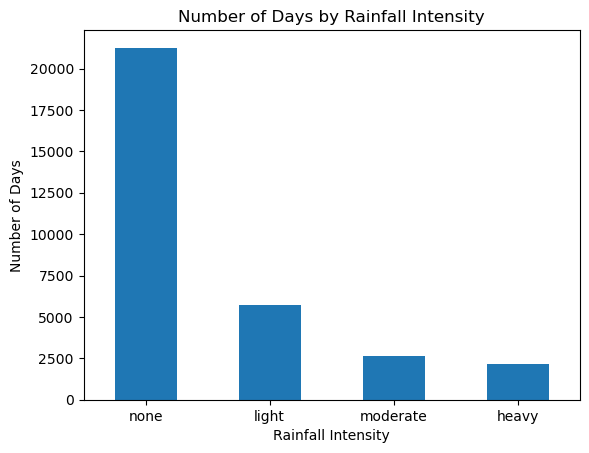

In [179]:
df["rainfall_intensity"].value_counts().plot(kind="bar")

plt.title("Number of Days by Rainfall Intensity")
plt.xlabel("Rainfall Intensity")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.show()

In [180]:
df.groupby("wind_category")["wspd"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
wind_category,,,,
breezy,1.1,4.9,2.567086,4530
calm,0.8,0.8,0.800000,1
windy,5.0,50.6,14.620989,27248


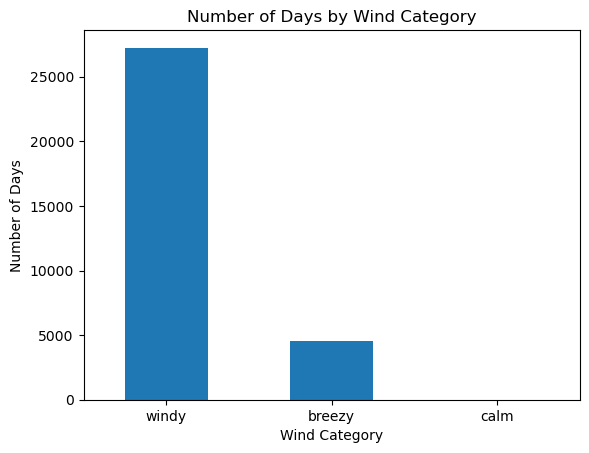

In [181]:
df["wind_category"].value_counts().plot(kind="bar")

plt.title("Number of Days by Wind Category")
plt.xlabel("Wind Category")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.show()

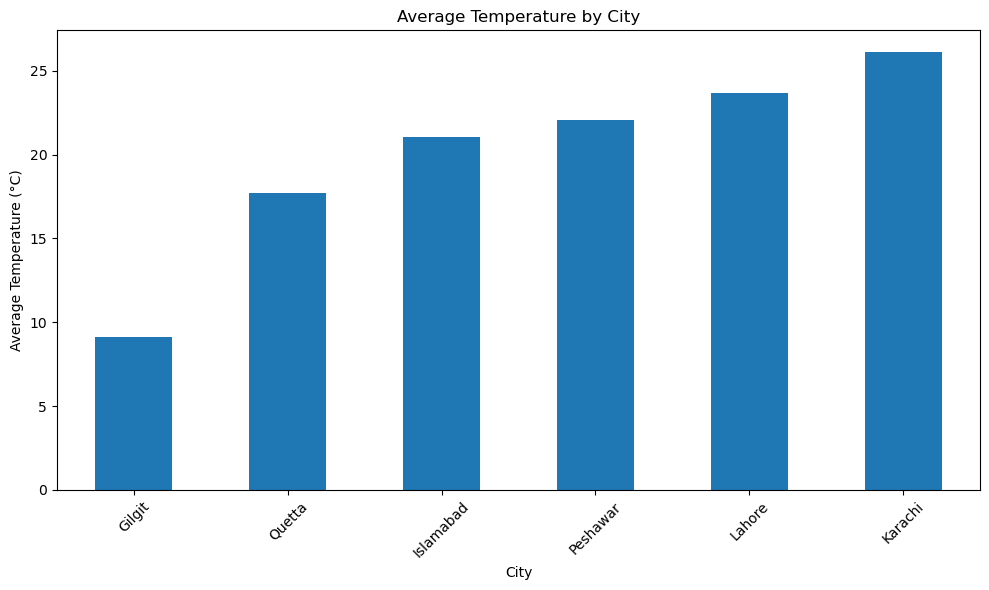

In [182]:
plt.figure(figsize=(10, 6))

city_temp = df.groupby("city")["tavg"].mean().sort_values()

city_temp.plot(kind="bar")

plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

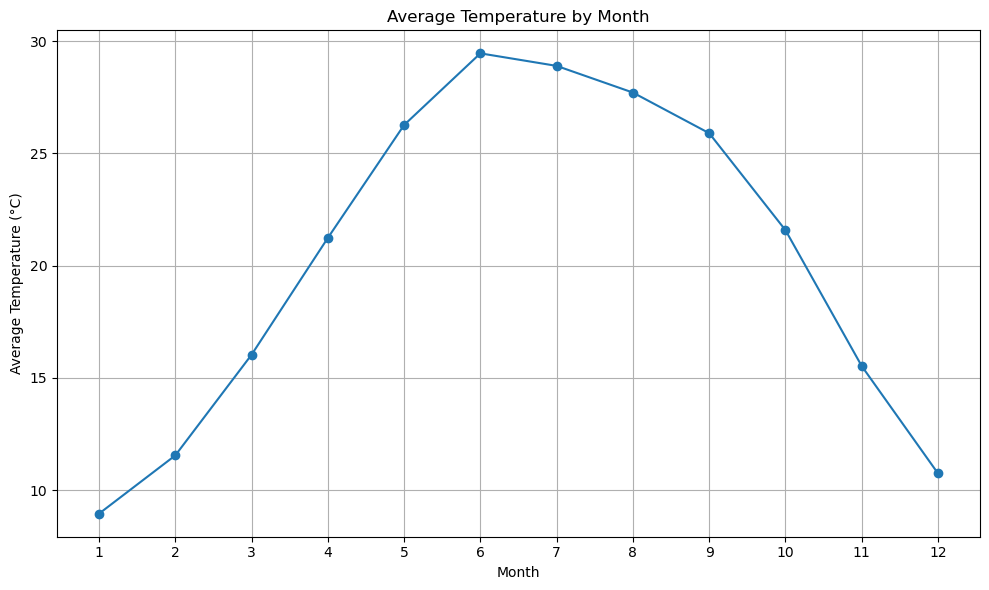

In [183]:
plt.figure(figsize=(10, 6))

monthly_temp = df.groupby("month")["tavg"].mean()

monthly_temp.plot(kind="line", marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

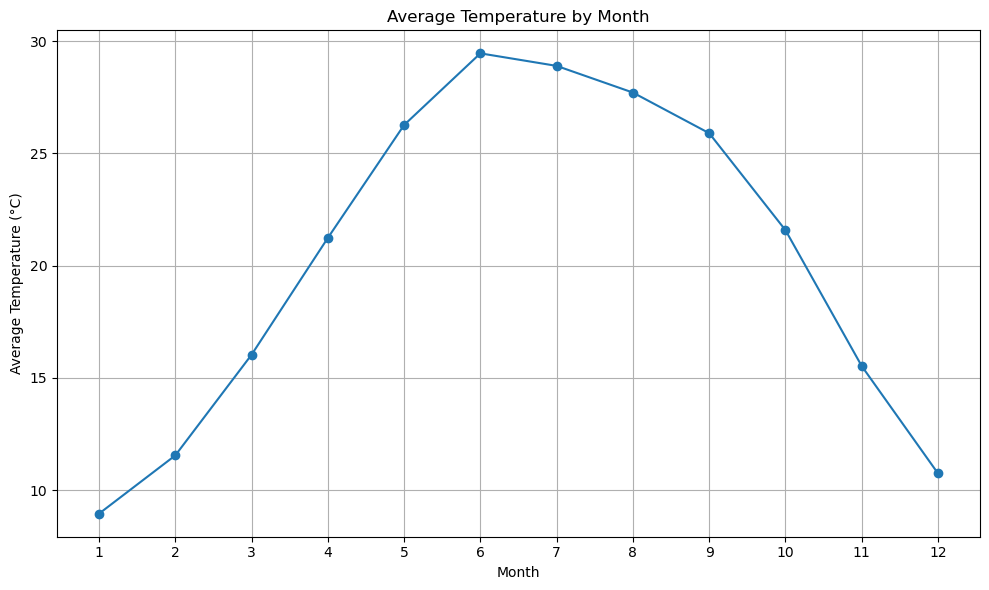

In [184]:
plt.figure(figsize=(10, 6))

monthly_temp = df.groupby("month")["tavg"].mean()

monthly_temp.plot(kind="line", marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

In [185]:
df.columns.tolist()

['date',
 'year',
 'month',
 'day',
 'dayofweek',
 'is_weekend',
 'season',
 'city',
 'region',
 'latitude',
 'longitude',
 'elevation',
 'tmin',
 'tmax',
 'tavg',
 'prcp',
 'wspd',
 'humidity',
 'pressure',
 'dew_point',
 'cloud_cover',
 'temp_range',
 'is_hot_day',
 'is_cold_day',
 'rainfall_intensity',
 'wind_category']

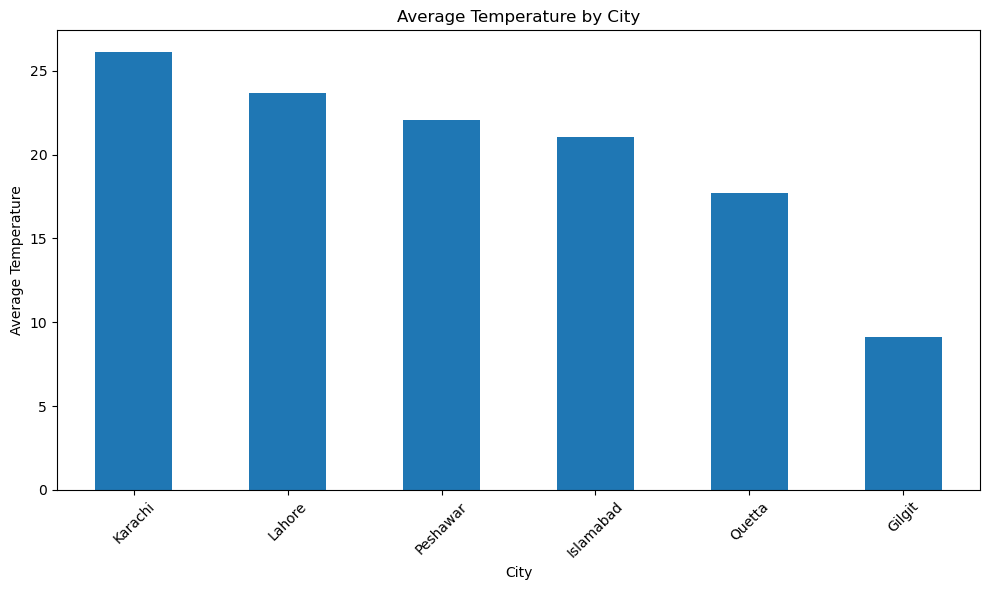

In [186]:
# Average Temperature by City

city_temp = df.groupby("city")["tavg"].mean().sort_values(ascending=False)

city_temp.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

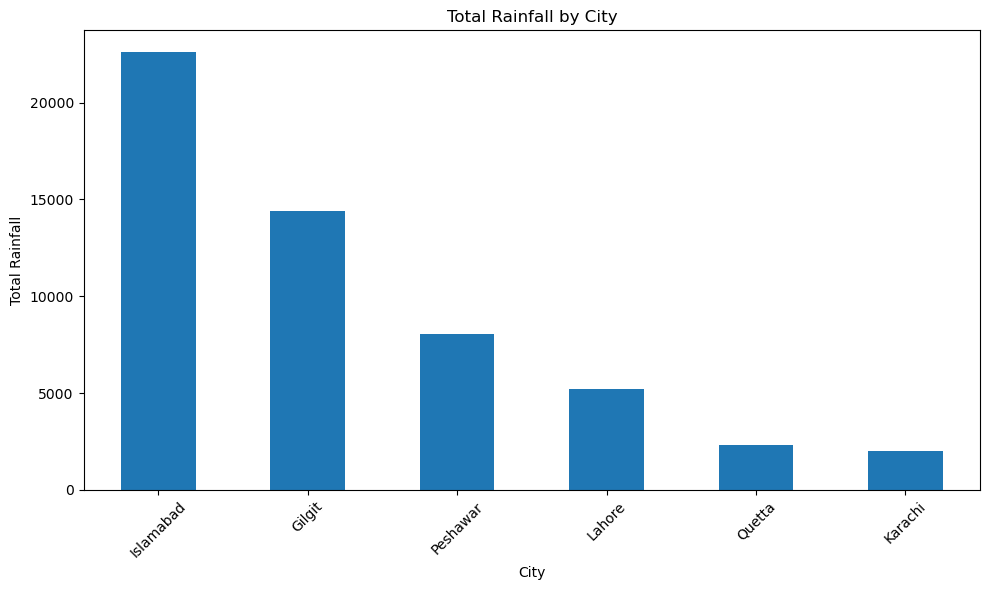

In [187]:
# Total Rainfall by City

city_rain = df.groupby("city")["prcp"].sum().sort_values(ascending=False)

city_rain.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total Rainfall by City")
plt.xlabel("City")
plt.ylabel("Total Rainfall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

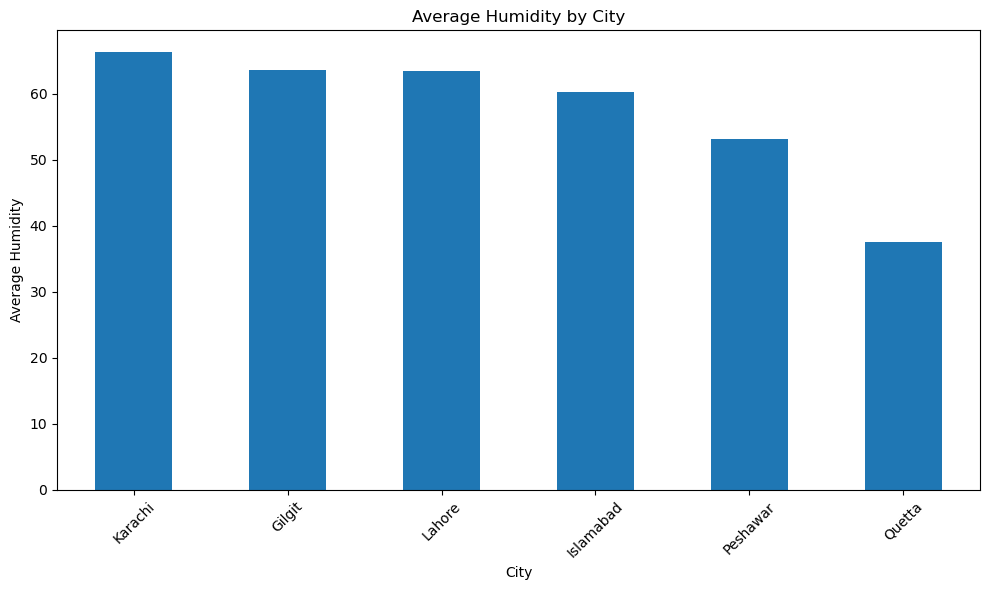

In [188]:
### Avergae humidity by city
# Average Humidity by City

city_humidity = df.groupby("city")["humidity"].mean().sort_values(ascending=False)

city_humidity.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Humidity by City")
plt.xlabel("City")
plt.ylabel("Average Humidity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

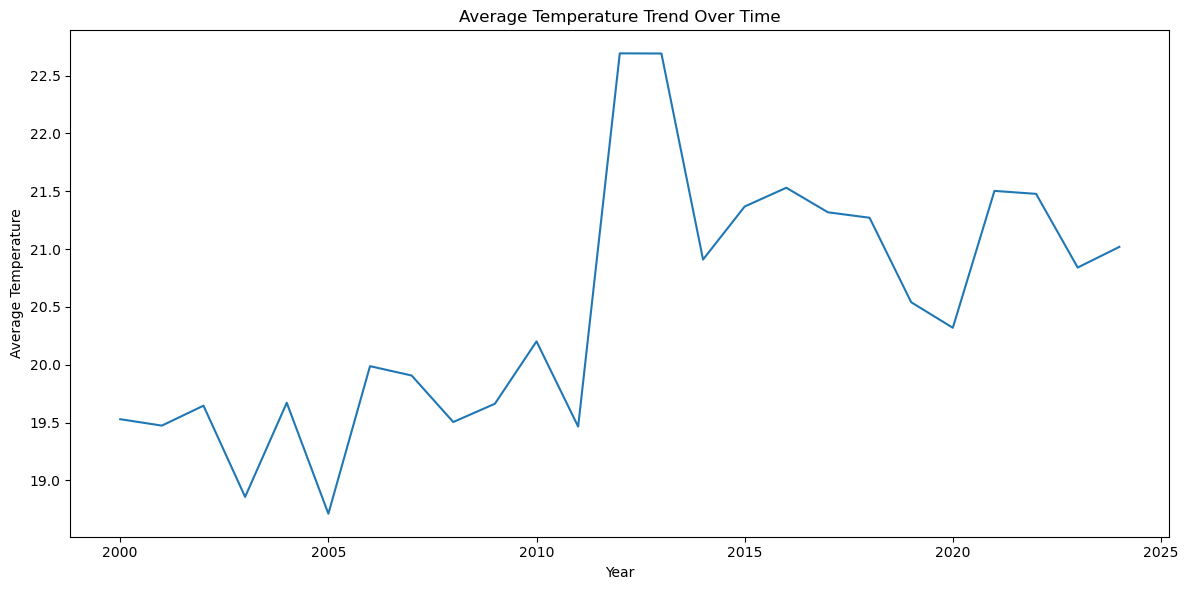

In [189]:
# Average Temperature by Year

yearly_temp = df.groupby("year")["tavg"].mean()

yearly_temp.plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("Average Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.tight_layout()
plt.show()

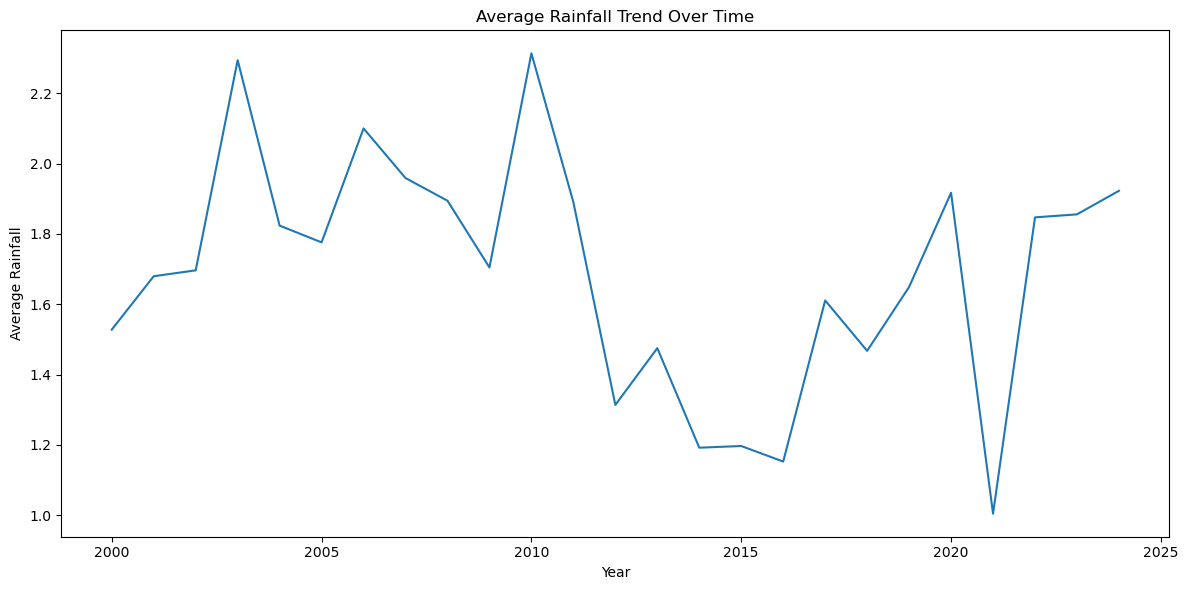

In [190]:
# Average Rainfall by Year

yearly_rain = df.groupby("year")["prcp"].mean()

yearly_rain.plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("Average Rainfall Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rainfall")
plt.tight_layout()
plt.show()

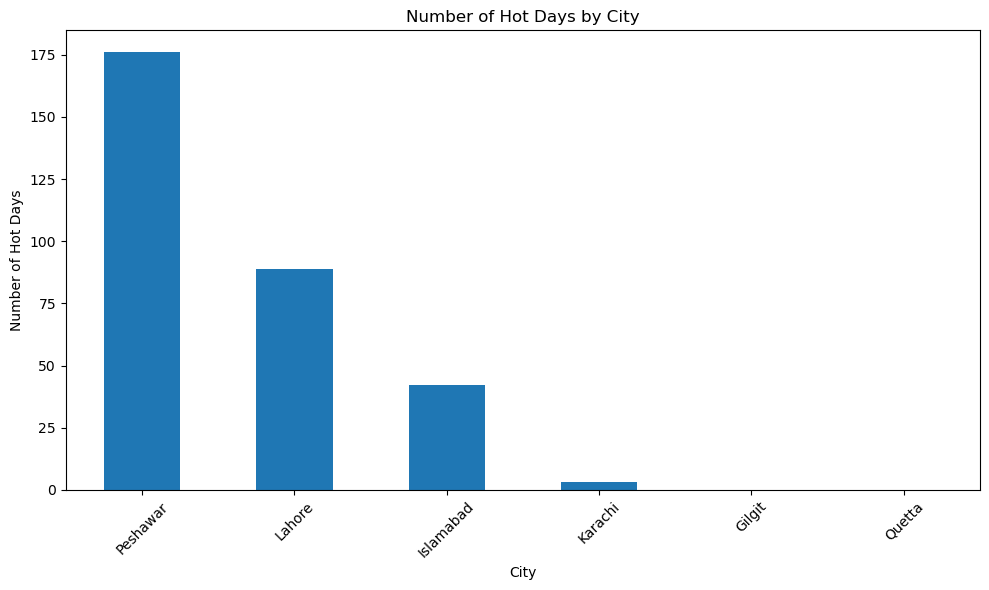

In [191]:
# Number of Hot Days by City

hot_days = df.groupby("city")["is_hot_day"].sum().sort_values(ascending=False)

hot_days.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Number of Hot Days by City")
plt.xlabel("City")
plt.ylabel("Number of Hot Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

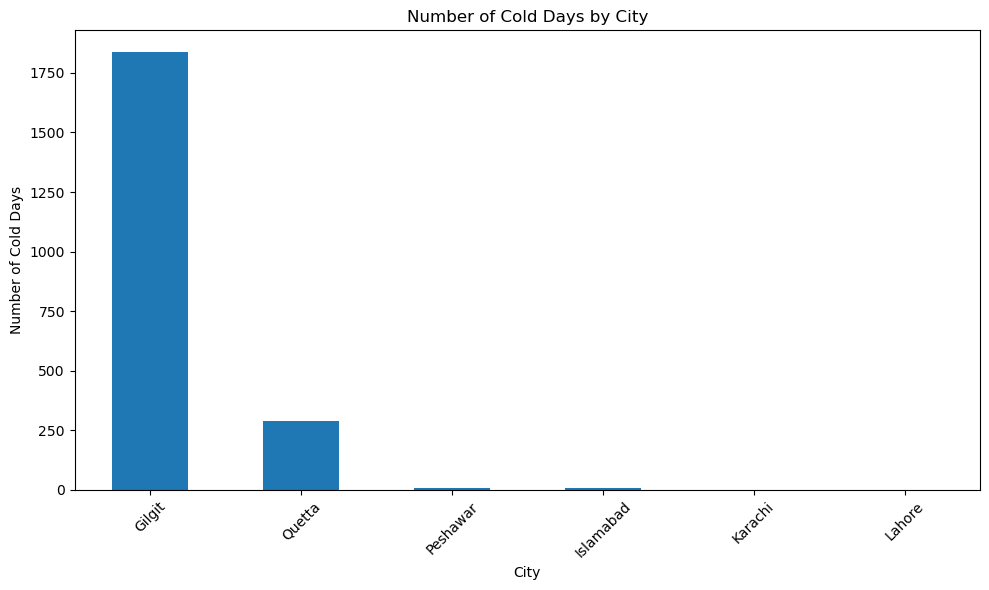

In [192]:
# Number of Cold Days by City

cold_days = df.groupby("city")["is_cold_day"].sum().sort_values(ascending=False)

cold_days.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Number of Cold Days by City")
plt.xlabel("City")
plt.ylabel("Number of Cold Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

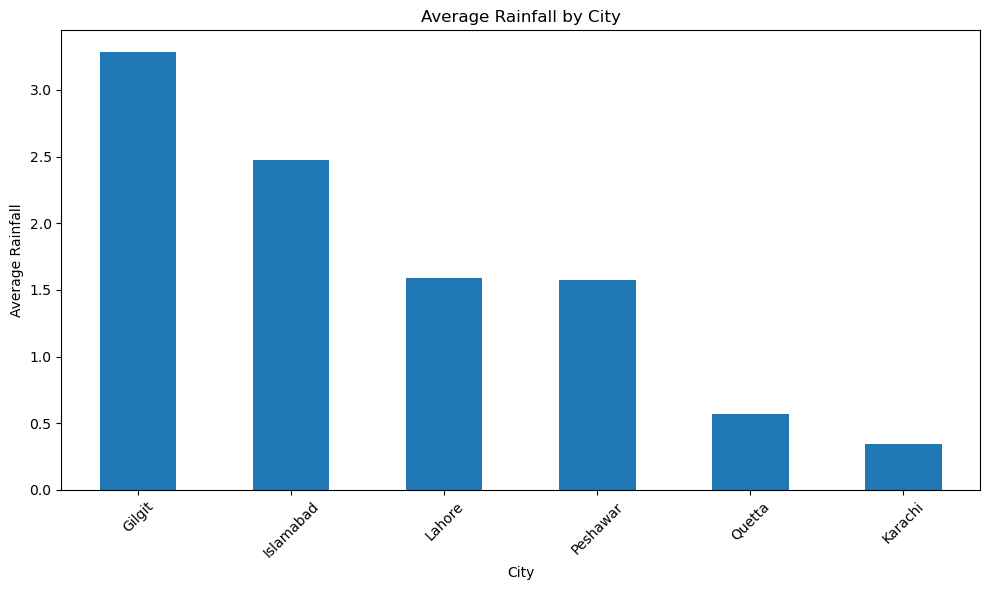

In [193]:
### Rainfall intensity by city


rain_intensity = df.groupby("city")["prcp"].mean().sort_values(ascending=False)

rain_intensity.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Rainfall by City")
plt.xlabel("City")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

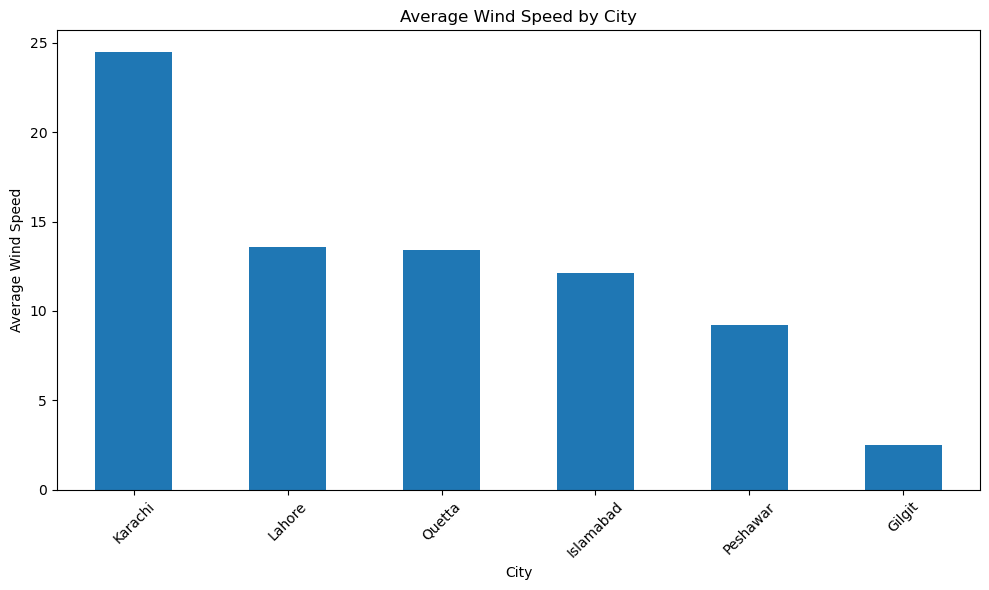

In [194]:
# Average Wind Speed by City

city_wind = df.groupby("city")["wspd"].mean().sort_values(ascending=False)

city_wind.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Wind Speed by City")
plt.xlabel("City")
plt.ylabel("Average Wind Speed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

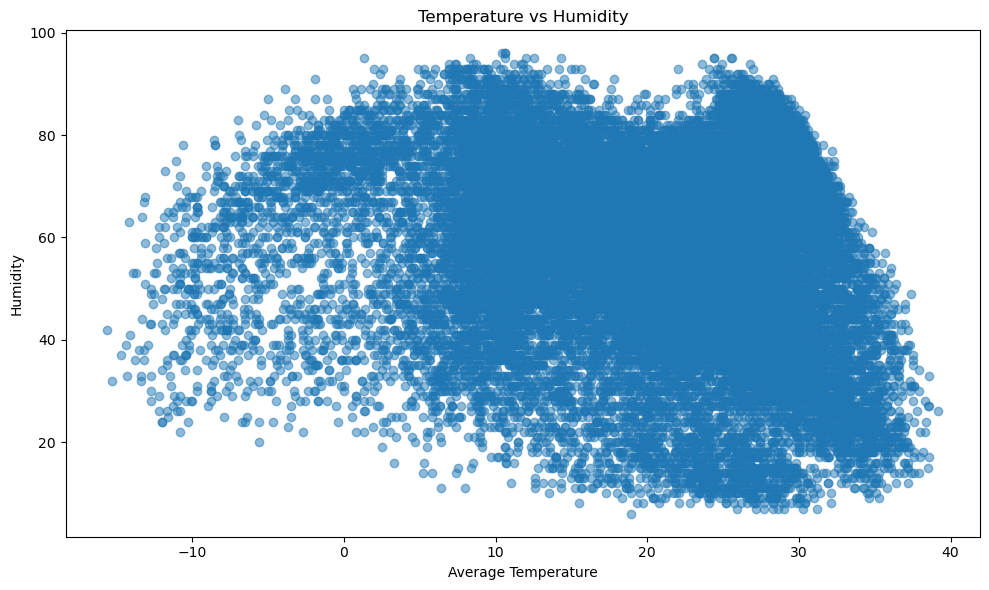

In [195]:
# Temperature vs Humidity

plt.figure(figsize=(10, 6))

plt.scatter(df["tavg"], df["humidity"], alpha=0.5)

plt.title("Temperature vs Humidity")
plt.xlabel("Average Temperature")
plt.ylabel("Humidity")

plt.tight_layout()
plt.show()

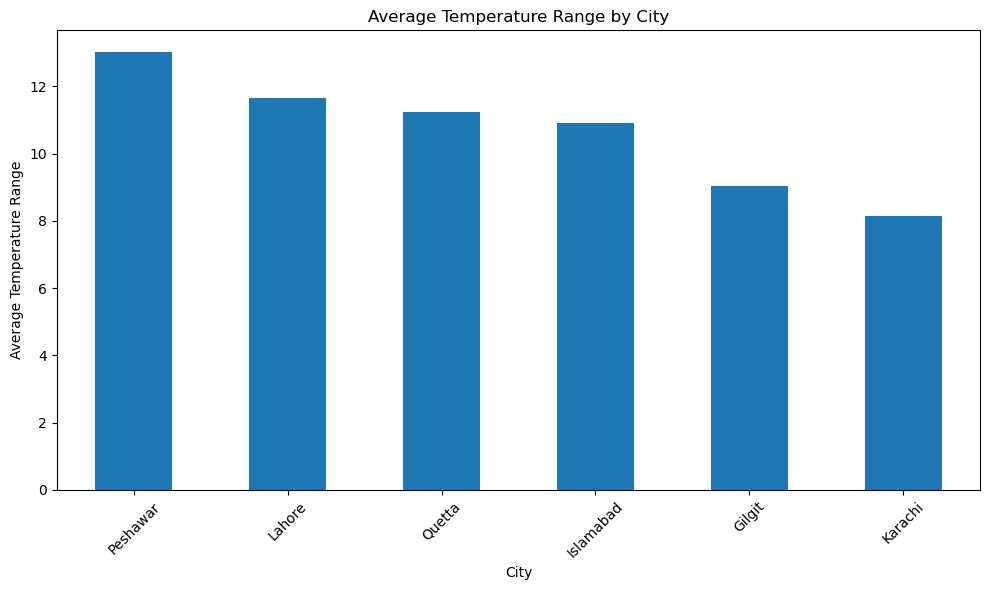

In [196]:
# Average Temperature Range by City

city_temp_range = df.groupby("city")["temp_range"].mean().sort_values(ascending=False)

city_temp_range.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Temperature Range by City")
plt.xlabel("City")
plt.ylabel("Average Temperature Range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

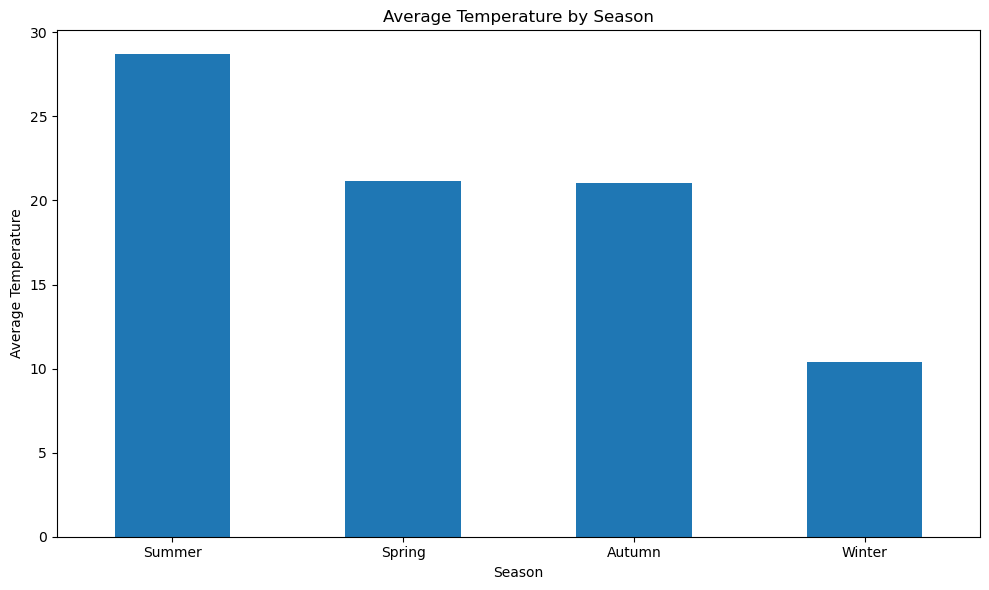

In [197]:
# Average Temperature by Season

season_temp = df.groupby("season")["tavg"].mean().sort_values(ascending=False)

season_temp.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

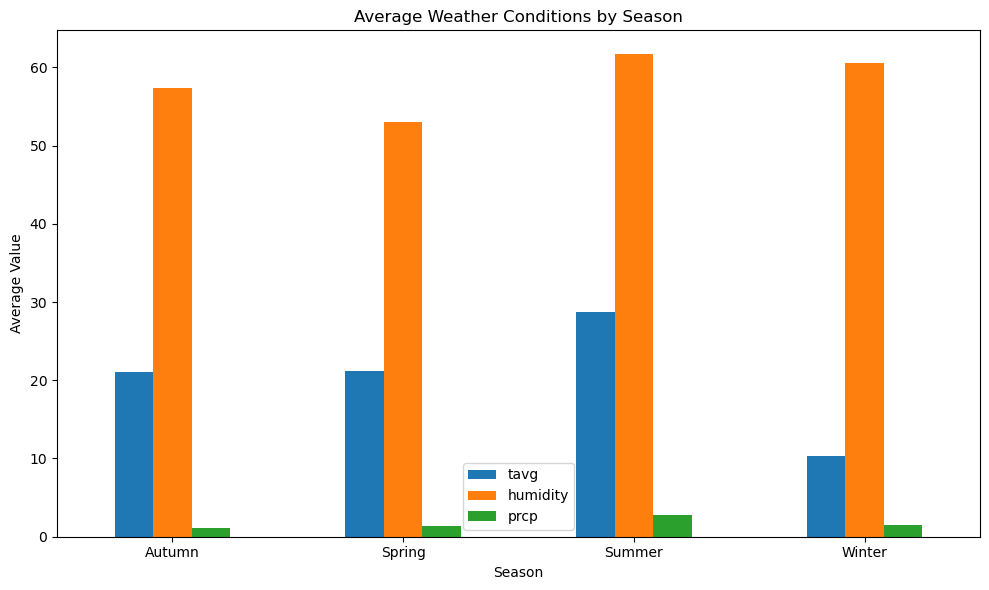

In [198]:
# Weather Conditions by Season

season_weather = df.groupby("season")[["tavg", "humidity", "prcp"]].mean()

season_weather.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Weather Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

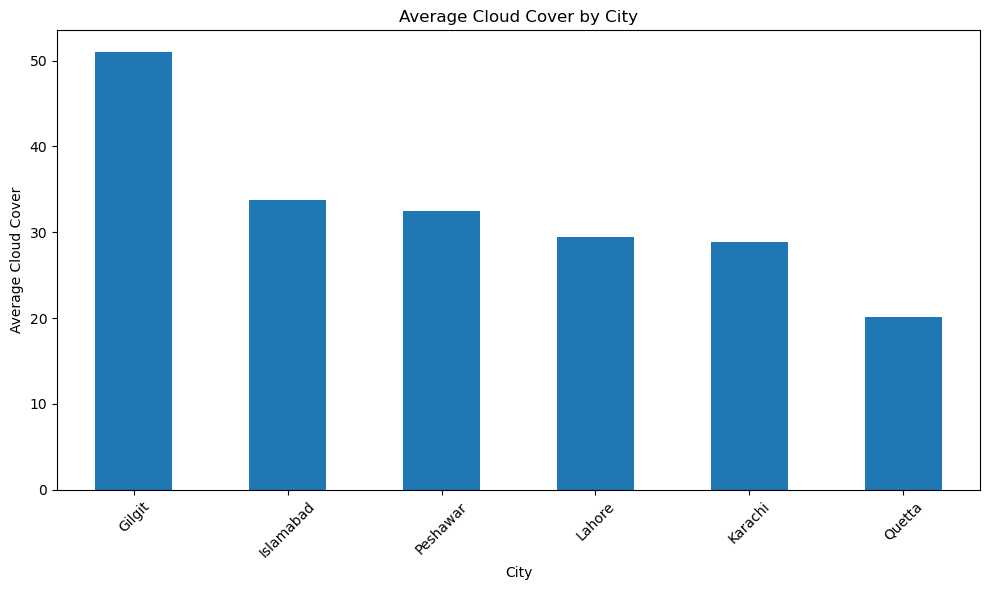

In [199]:
# Average Cloud Cover by City

city_cloud = df.groupby("city")["cloud_cover"].mean().sort_values(ascending=False)

city_cloud.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Cloud Cover by City")
plt.xlabel("City")
plt.ylabel("Average Cloud Cover")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

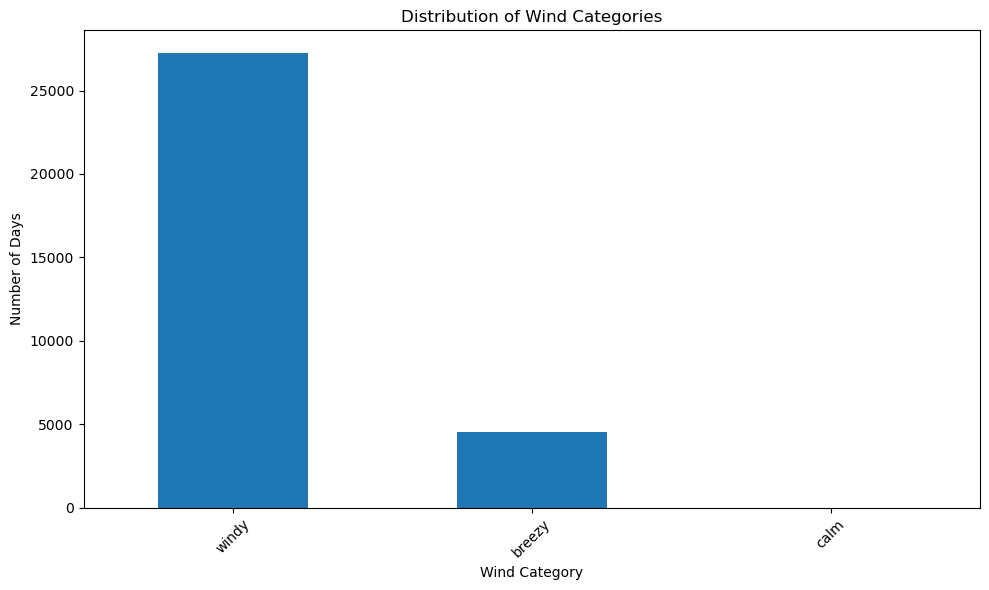

In [200]:
# Wind Category Distribution

wind_counts = df["wind_category"].value_counts()

wind_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribution of Wind Categories")
plt.xlabel("Wind Category")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

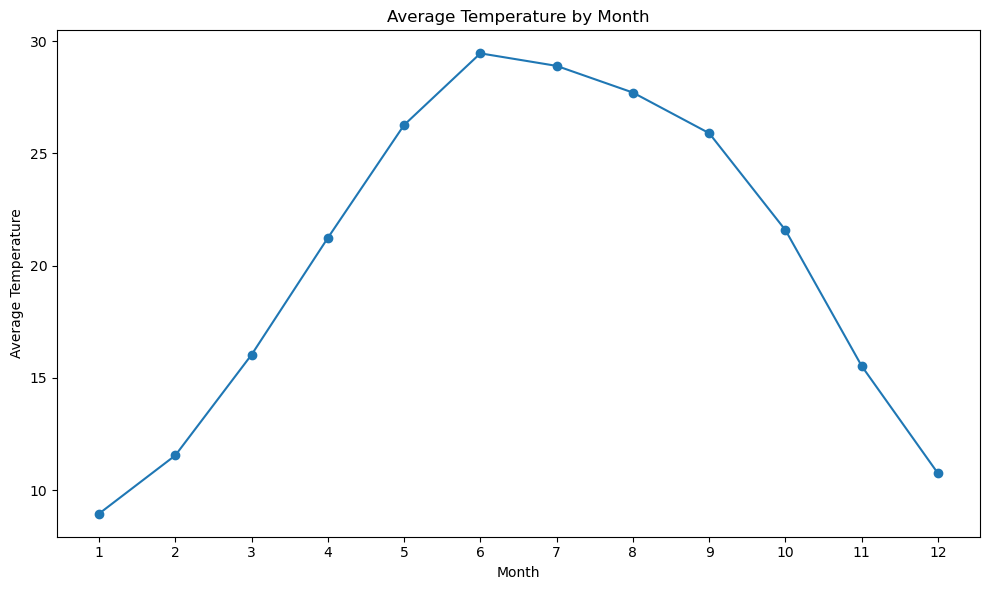

In [201]:
# Average Temperature by Month

monthly_temp = df.groupby("month")["tavg"].mean()

monthly_temp.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

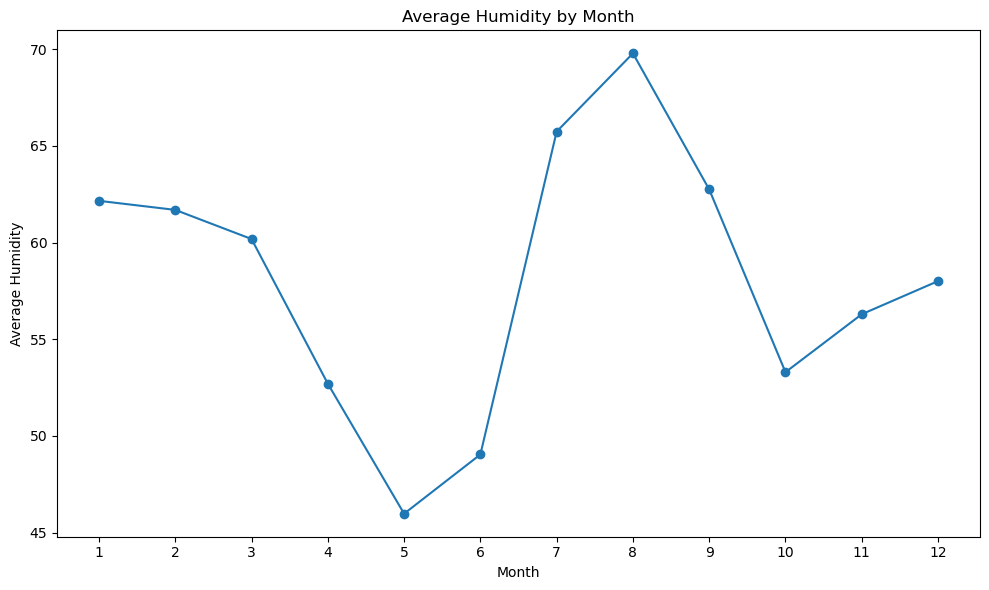

In [202]:
# Average Humidity by Month

monthly_humidity = df.groupby("month")["humidity"].mean()

monthly_humidity.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Average Humidity by Month")
plt.xlabel("Month")
plt.ylabel("Average Humidity")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

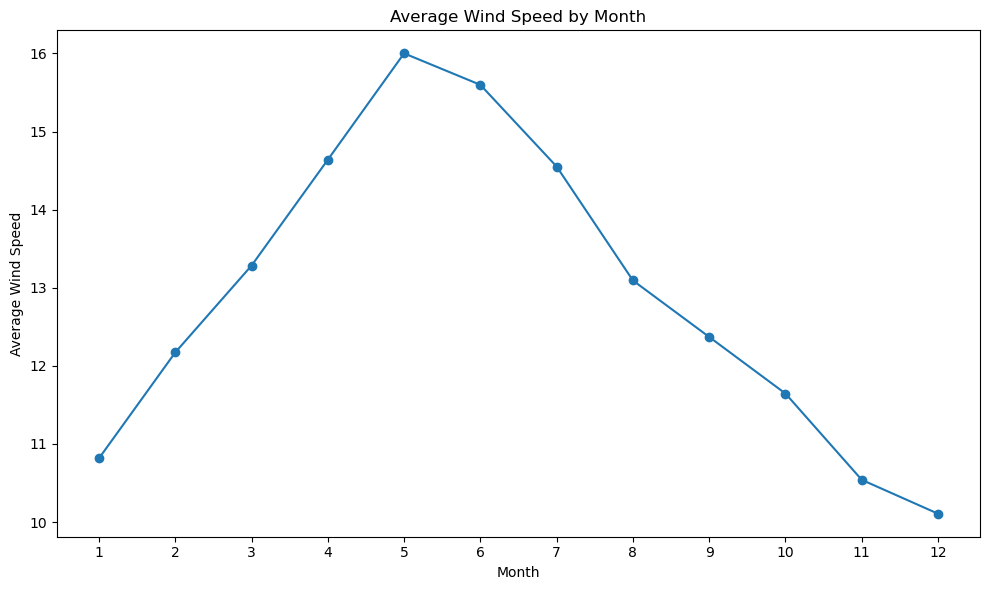

In [203]:
# Average Wind Speed by Month

monthly_wind = df.groupby("month")["wspd"].mean()

monthly_wind.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Average Wind Speed by Month")
plt.xlabel("Month")
plt.ylabel("Average Wind Speed")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

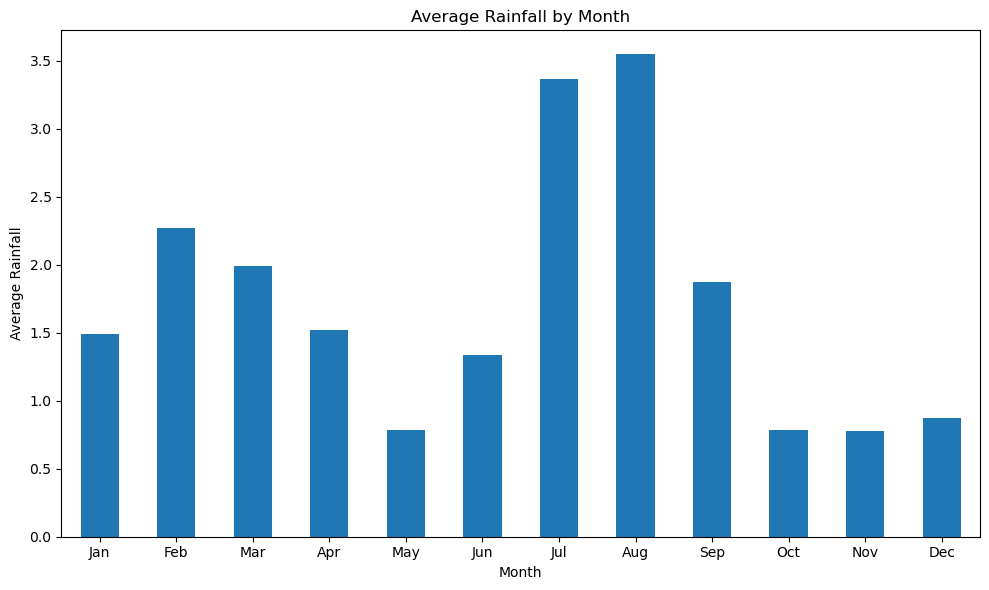

In [204]:
# Average Rainfall by Month

monthly_rain = df.groupby("month")["prcp"].mean()

monthly_rain.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Average Rainfall")
plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
], rotation=0)

plt.tight_layout()
plt.show()

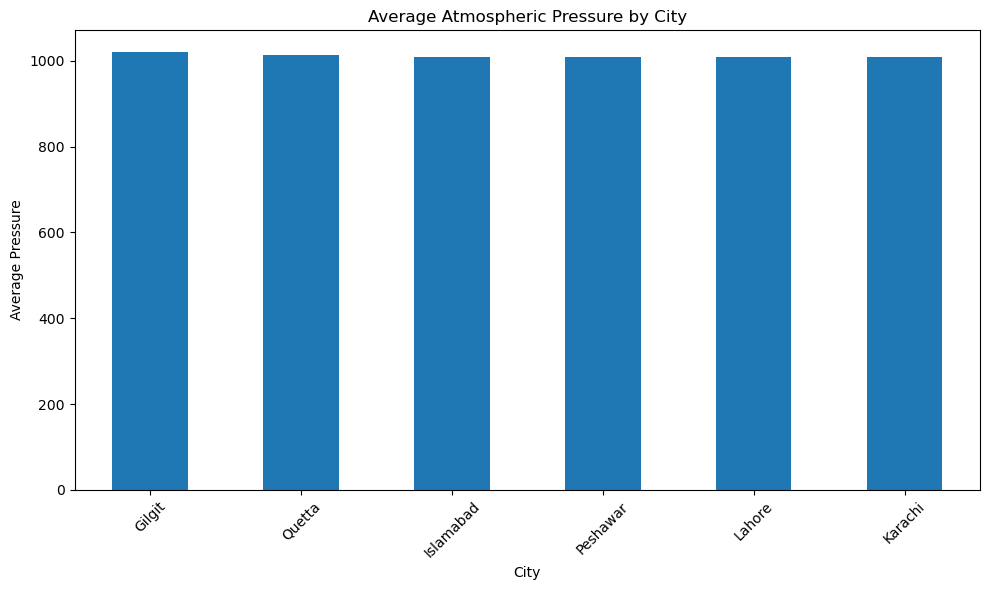

In [205]:
# Average Atmospheric Pressure by City

city_pressure = df.groupby("city")["pressure"].mean().sort_values(ascending=False)

city_pressure.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Atmospheric Pressure by City")
plt.xlabel("City")
plt.ylabel("Average Pressure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

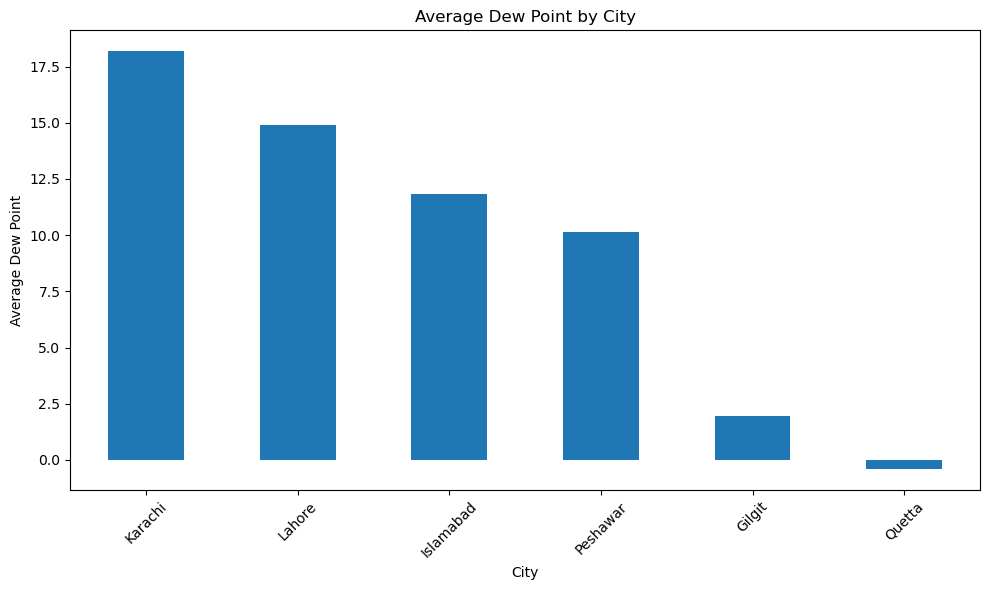

In [206]:
# Average Dew Point by City

city_dew = df.groupby("city")["dew_point"].mean().sort_values(ascending=False)

city_dew.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Dew Point by City")
plt.xlabel("City")
plt.ylabel("Average Dew Point")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

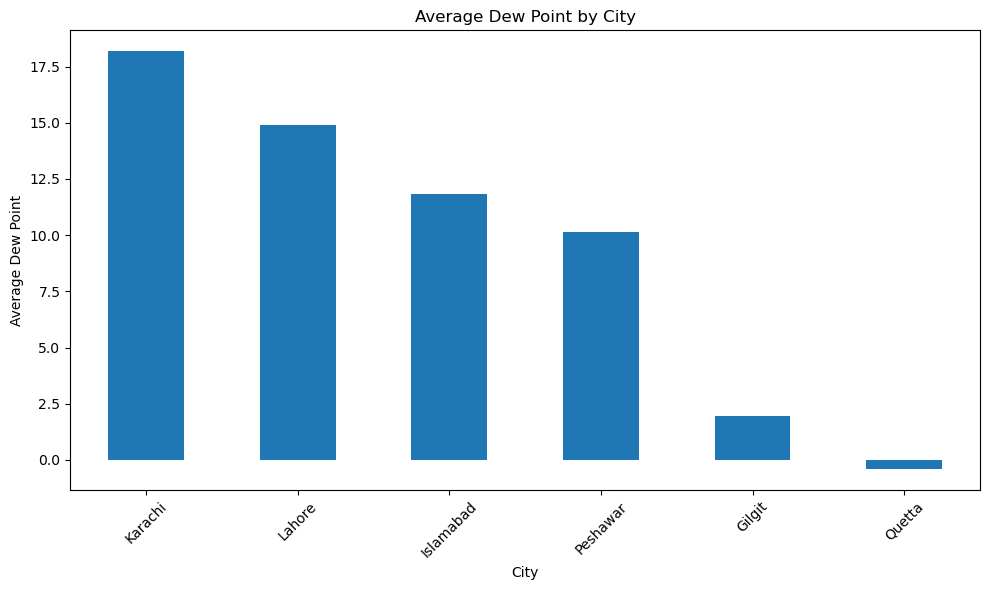

In [207]:
# Average Dew Point by City

city_dew = df.groupby("city")["dew_point"].mean().sort_values(ascending=False)

city_dew.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Dew Point by City")
plt.xlabel("City")
plt.ylabel("Average Dew Point")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

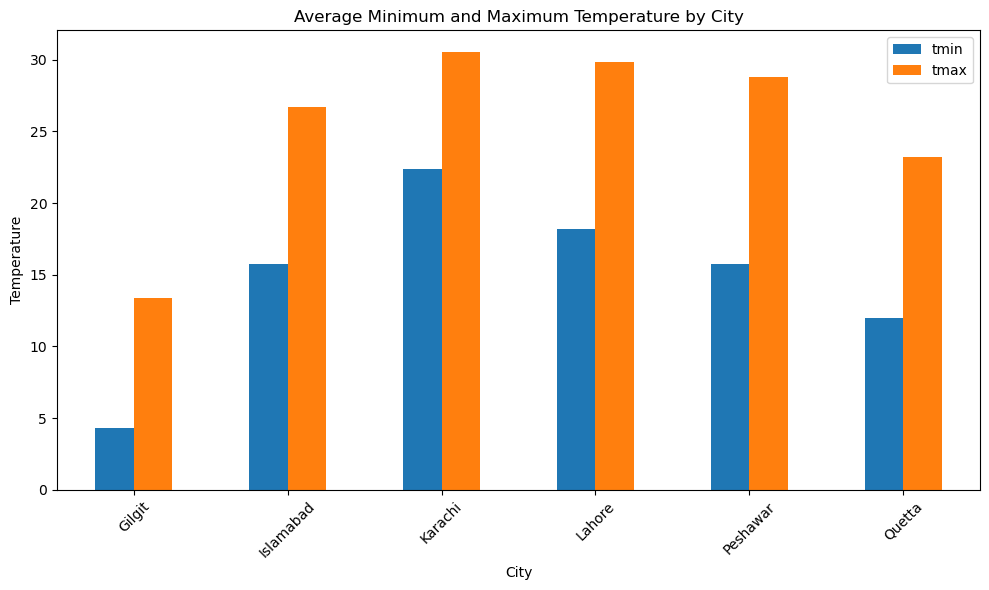

In [208]:
# Average Minimum and Maximum Temperature by City

city_temp = df.groupby("city")[["tmin", "tmax"]].mean()

city_temp.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Minimum and Maximum Temperature by City")
plt.xlabel("City")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [209]:
# Final Key Statistics

print("Hottest City (Average):")
print(df.groupby("city")["tavg"].mean().idxmax())

print("\nColdest City (Average):")
print(df.groupby("city")["tavg"].mean().idxmin())

print("\nCity with Most Hot Days:")
print(df.groupby("city")["is_hot_day"].sum().idxmax())

print("\nCity with Most Cold Days:")
print(df.groupby("city")["is_cold_day"].sum().idxmax())

print("\nWettest City (Average Rainfall):")
print(df.groupby("city")["prcp"].mean().idxmax())

print("\nHighest Average Humidity City:")
print(df.groupby("city")["humidity"].mean().idxmax())

Hottest City (Average):
Karachi

Coldest City (Average):
Gilgit

City with Most Hot Days:
Peshawar

City with Most Cold Days:
Gilgit

Wettest City (Average Rainfall):
Gilgit

Highest Average Humidity City:
Karachi


## Conclusion

This weather data analysis explored weather patterns across different cities and over time. The analysis examined temperature, rainfall, humidity, wind speed, cloud cover, dew point, and other weather variables.

The results showed clear differences between cities. Karachi recorded the highest average temperature and humidity, while Gilgit recorded the lowest average temperature and the highest number of cold days. Peshawar had the highest number of hot days, while Gilgit also recorded the highest average rainfall.

The visualizations also revealed seasonal and yearly variations in weather conditions. Overall, this analysis demonstrates how Python, Pandas, and data visualization can be used to clean, analyze, and understand large weather datasets and identify meaningful patterns.
